# Assignment 02 — Dark Kitchen Rental Geography

**Question:** How does the spatial distribution of high-confidence dark kitchens relate to the rental geography of delivery-oriented commercial space in Beijing?

The dark-kitchen locations come from my own platform investigation. Rental listings are used as a related dataset to describe the local asking-rent environment.


## Data


In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from pathlib import Path
from shapely.geometry import Polygon


In [2]:
beijing = gpd.read_file("北京市_3857.shp").to_crs("EPSG:3857")

rent = pd.read_csv("rent_merged_clean.csv")
rent["lat"] = pd.to_numeric(rent["lat"], errors="coerce")
rent["lng"] = pd.to_numeric(rent["lng"], errors="coerce")
rent["rent"] = pd.to_numeric(rent["rent_day_yuan_per_sqm_est"], errors="coerce")

rent = rent.dropna(subset=["lat", "lng", "rent", "source"]).copy()
rent = rent[rent["source"].isin(["bright", "dark"])].copy()

rent_gdf = gpd.GeoDataFrame(
    rent,
    geometry=gpd.points_from_xy(rent["lng"], rent["lat"]),
    crs="EPSG:4326",
).to_crs("EPSG:3857")


In [3]:
dark_yes = pd.read_csv("BJ_暗店_yes.csv")
dark_yes["lat"] = pd.to_numeric(dark_yes["lat"], errors="coerce")
dark_yes["lng"] = pd.to_numeric(dark_yes["lng"], errors="coerce")
dark_yes = dark_yes.dropna(subset=["lat", "lng"]).copy()

dark_yes_gdf = gpd.GeoDataFrame(
    dark_yes,
    geometry=gpd.points_from_xy(dark_yes["lng"], dark_yes["lat"]),
    crs="EPSG:4326",
).to_crs("EPSG:3857")


## Dark Kitchens


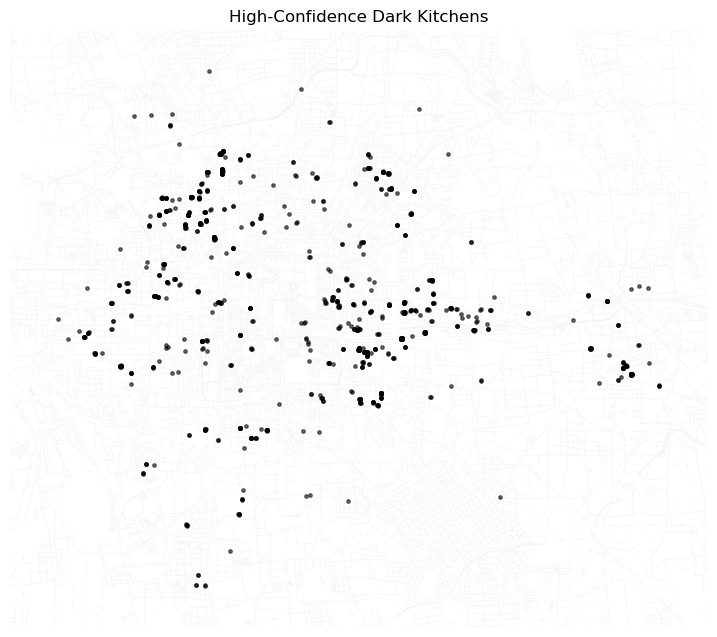

In [4]:
fig, ax = plt.subplots(figsize=(9, 9))

beijing.plot(
    ax=ax,
    facecolor="none",
    edgecolor="#e6e6e6",
    linewidth=0.2,
    alpha=0.5,
)

dark_yes_gdf.plot(
    ax=ax,
    color="black",
    markersize=6,
    alpha=0.55,
)

xmin, ymin, xmax, ymax = dark_yes_gdf.total_bounds
pad_x = (xmax - xmin) * 0.08
pad_y = (ymax - ymin) * 0.08

ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

ax.set_title("High-Confidence Dark Kitchens")
ax.set_axis_off()

plt.show()


## Hex Grid


In [5]:
def make_hexagon(cx, cy, radius):
    angles = np.deg2rad([0, 60, 120, 180, 240, 300])
    return Polygon([
        (cx + radius * np.cos(a), cy + radius * np.sin(a))
        for a in angles
    ])


In [6]:
xmin, ymin, xmax, ymax = rent_gdf.total_bounds

radius = 1800
hex_height = np.sqrt(3) * radius
hexagons = []

for col, x in enumerate(
    np.arange(xmin - 2 * radius, xmax + 2 * radius, 1.5 * radius)
):
    y_offset = hex_height / 2 if col % 2 else 0

    for y in np.arange(
        ymin - hex_height,
        ymax + hex_height,
        hex_height,
    ):
        hexagons.append(
            make_hexagon(x, y + y_offset, radius)
        )

grid = gpd.GeoDataFrame(
    {"grid_id": range(len(hexagons))},
    geometry=hexagons,
    crs="EPSG:3857",
)


In [7]:
rent_grid = gpd.sjoin(
    rent_gdf,
    grid[["grid_id", "geometry"]],
    how="left",
    predicate="within",
)

dark_with_grid = gpd.sjoin(
    dark_yes_gdf,
    grid[["grid_id", "geometry"]],
    how="inner",
    predicate="within",
)


## Rental Geography


In [8]:
bright_grid = (
    rent_grid[rent_grid["source"] == "bright"]
    .groupby("grid_id")
    .agg(
        bright_median_rent=("rent", "median"),
        bright_count=("rent", "size"),
    )
    .reset_index()
)

dark_grid = (
    rent_grid[rent_grid["source"] == "dark"]
    .groupby("grid_id")
    .agg(
        dark_median_rent=("rent", "median"),
        dark_count=("rent", "size"),
    )
    .reset_index()
)

grid_rent = (
    grid
    .merge(bright_grid, on="grid_id", how="left")
    .merge(dark_grid, on="grid_id", how="left")
)


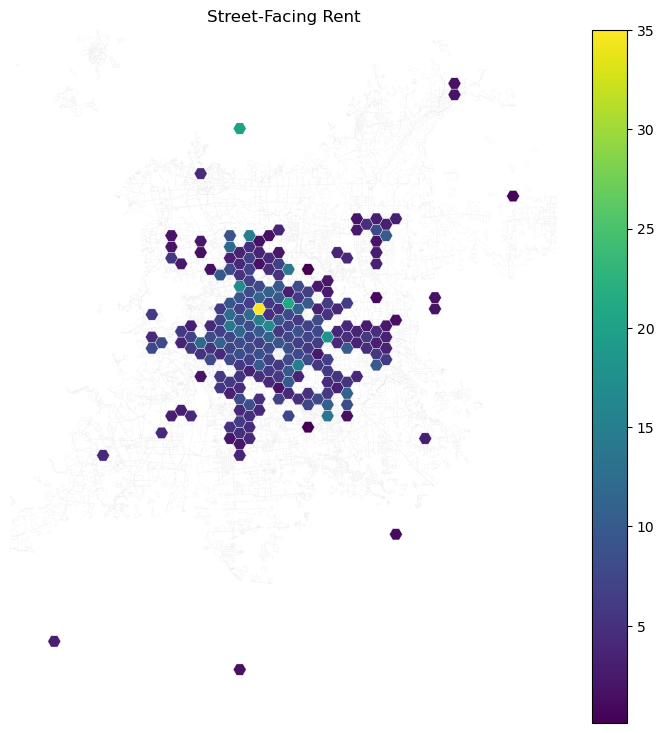

In [9]:
fig, ax = plt.subplots(figsize=(9, 9))

beijing.plot(
    ax=ax,
    facecolor="none",
    edgecolor="#e6e6e6",
    linewidth=0.2,
    alpha=0.5,
)

bright_layer = grid_rent.dropna(subset=["bright_median_rent"])

bright_layer.plot(
    ax=ax,
    column="bright_median_rent",
    cmap="viridis",
    legend=True,
    edgecolor="white",
    linewidth=0.25,
)

xmin, ymin, xmax, ymax = bright_layer.total_bounds
pad_x = (xmax - xmin) * 0.08
pad_y = (ymax - ymin) * 0.08

ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

ax.set_title("Street-Facing Rent")
ax.set_axis_off()

plt.show()


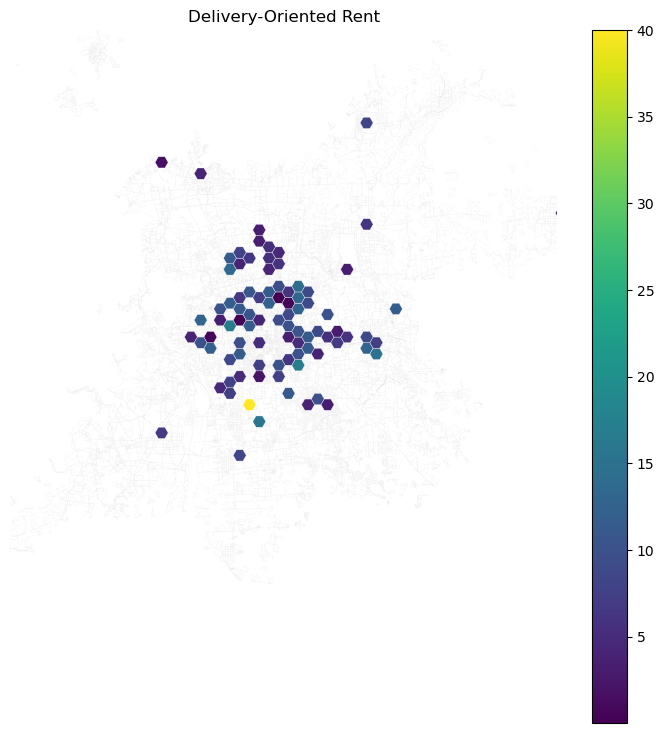

In [18]:
fig, ax = plt.subplots(figsize=(9, 9))

beijing.plot(
    ax=ax,
    facecolor="none",
    edgecolor="#e6e6e6",
    linewidth=0.2,
    alpha=0.5,
)

dark_layer = grid_rent.dropna(subset=["dark_median_rent"])

dark_layer.plot(
    ax=ax,
    column="dark_median_rent",
    cmap="viridis",
    legend=True,
    edgecolor="white",
    linewidth=0.25,
)

xmin, ymin, xmax, ymax = bright_layer.total_bounds
pad_x = (xmax - xmin) * 0.08
pad_y = (ymax - ymin) * 0.08

ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

ax.set_title("Delivery-Oriented Rent")
ax.set_axis_off()

plt.show()


## Rent Difference


In [11]:
comparison_grid = grid_rent.dropna(
    subset=["bright_median_rent", "dark_median_rent"]
).copy()

comparison_grid["rent_gap"] = (
    comparison_grid["bright_median_rent"]
    - comparison_grid["dark_median_rent"]
)


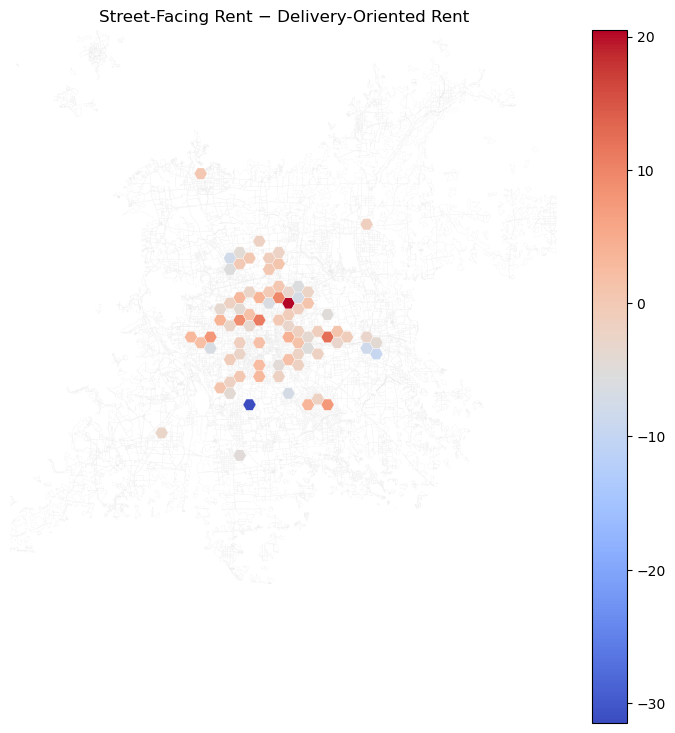

In [19]:
fig, ax = plt.subplots(figsize=(9, 9))

beijing.plot(
    ax=ax,
    facecolor="none",
    edgecolor="#e6e6e6",
    linewidth=0.2,
    alpha=0.5,
)

comparison_grid.plot(
    ax=ax,
    column="rent_gap",
    cmap="coolwarm",
    legend=True,
    edgecolor="white",
    linewidth=0.25,
)

xmin, ymin, xmax, ymax = bright_layer.total_bounds
pad_x = (xmax - xmin) * 0.08
pad_y = (ymax - ymin) * 0.08

ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

ax.set_title("Street-Facing Rent − Delivery-Oriented Rent")
ax.set_axis_off()

plt.show()


## Dark Kitchen Concentration


In [13]:
dark_counts = (
    dark_with_grid
    .groupby("grid_id")
    .size()
    .reset_index(name="dark_kitchen_count")
)

analysis_grid = (
    grid_rent
    .dropna(subset=["dark_median_rent"])
    .merge(dark_counts, on="grid_id", how="left")
)

analysis_grid["dark_kitchen_count"] = (
    analysis_grid["dark_kitchen_count"]
    .fillna(0)
    .astype(int)
)


In [14]:
analysis_grid["rent_level"] = pd.qcut(
    analysis_grid["dark_median_rent"],
    q=3,
    labels=["Low", "Medium", "High"],
)

rent_summary = (
    analysis_grid
    .groupby("rent_level", observed=True)
    .agg(
        hex_count=("grid_id", "count"),
        dark_kitchens=("dark_kitchen_count", "sum"),
        avg_dark_kitchens_per_hex=("dark_kitchen_count", "mean"),
        median_rent=("dark_median_rent", "median"),
    )
    .reset_index()
)

rent_summary


,rent_level,hex_count,dark_kitchens,avg_dark_kitchens_per_hex,median_rent
0,Low,30,156,5.200000,3.872500
1,Medium,31,128,4.129032,8.000000
2,High,28,363,12.964286,11.553333


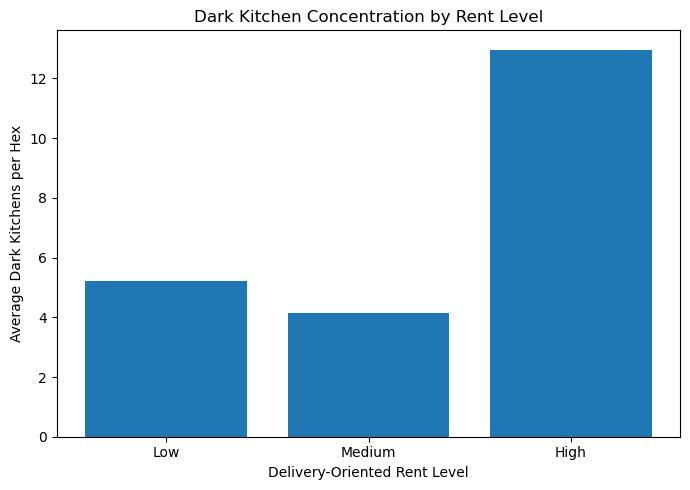

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    rent_summary["rent_level"],
    rent_summary["avg_dark_kitchens_per_hex"],
)

ax.set_xlabel("Delivery-Oriented Rent Level")
ax.set_ylabel("Average Dark Kitchens per Hex")
ax.set_title("Dark Kitchen Concentration by Rent Level")

plt.tight_layout()
plt.show()


## Finding

Within the hexes covered by the rental dataset, high-confidence dark kitchens are more concentrated in the higher-rent delivery-oriented group. This does not show that higher rent causes dark-kitchen concentration; it suggests that rent alone does not explain location choice.

Empty rental cells are treated as missing observations, not as zero rent.


## 3D Map


In [16]:
analysis_grid.to_crs("EPSG:4326").to_file(
    "dark_kitchen_rent_3d.geojson",
    driver="GeoJSON",
)


The 3D map combines the two variables used in the final comparison:

- **Color** = median delivery-oriented rent
- **Height** = high-confidence dark-kitchen count

![3D Dark Kitchen Map](dark_kitchen_3d_map.png)

[Open the interactive 3D map](web_map/index.html)


## Workflow

Dark-kitchen observations  
→ map high-confidence locations  
→ assign points to a shared hex grid  
→ count dark kitchens per hex  

Rental listings  
→ separate street-facing and delivery-oriented samples  
→ assign listings to the same hex grid  
→ calculate median rent per hex  
→ compare the two rental geographies  

Dark-kitchen count + delivery-oriented rent  
→ final 3D visualization

![Workflow Diagram](workflow.png)
